In [41]:
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

## Data Preprocesing

### 1. Handle Missing Values


In [7]:
df["Income"] = df["Income"].fillna(df["Income"].median())

### 2. Feature Engineering


In [8]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='str')

In [ ]:
#Age
df['Age'] = 2026 - df["Year_Birth"]

In [ ]:
#Customer Joining Date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

reference_date = df["Dt_Customer"].max()
df["Customer_Tenuer_Days"] = (reference_date - df['Dt_Customer']).dt.days

In [17]:
# Spending

df["Total_Spending"] = df['MntWines'] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [19]:
# children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [ ]:
# Education
df['Education'].value_counts()
#There are 5 categories = "Graduation, PhD, Master, 2n Cycle, Basic"
#I converge it to 3 categories = "Postgraduate, Graduate, Undergraduate"

df["Education"] = df["Education"].replace({
    "Basic":"Undergraduate",
    "2n Cycle":"Undergraduate",
    "Graduation": "Graduate",
    "PhD": "Postgraduate",
    "Master": "Postgraduate"
})

In [29]:
df["Marital_Status"].value_counts()

#Marital Status

df["Living_With"] = df['Marital_Status'].replace({
    "Married":"Partner",
    "Together":"Partner",
    "Single": "Alone",
    "Divorced": "Alone",
    "Widow": "Alone",
    "Absurd": "Alone",
    "YOLO": "Alone"
}) 
df['Living_With'].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

### 3. Drop Unnecessery Columns


In [35]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
cols_to_drop = cols + spending_cols
df_cleaned = df.drop(columns=cols_to_drop)

### 4. Detecting and Deleting Outliers


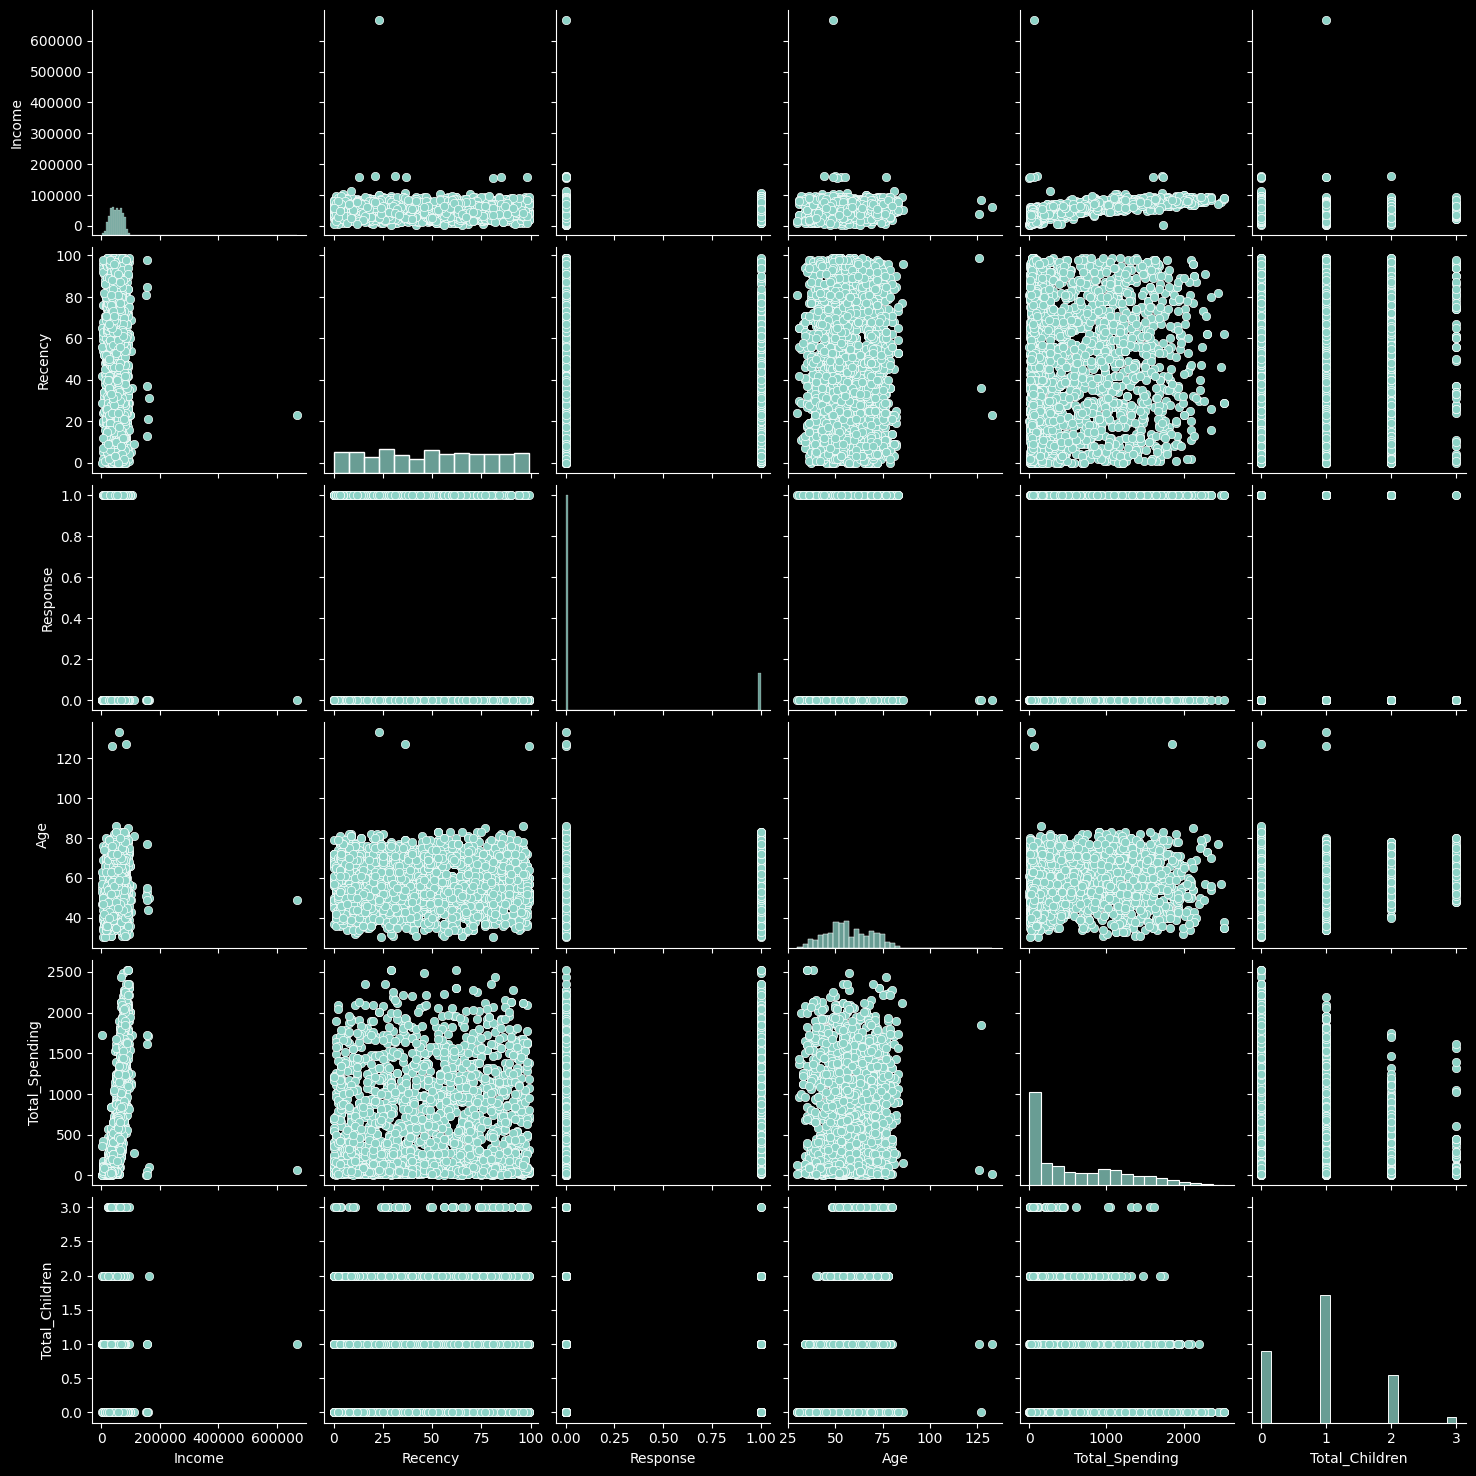

In [43]:
cols = ['Income', 'Recency', 'Response', 'Age', 'Total_Spending', 'Total_Children']
# relative plots of some features - pair plots
sns.pairplot(df_cleaned[cols])

In [45]:
# outlier detects at-
#1. income > 60000
#2. age > 90
print("data size with outliers: ", len(df_cleaned))
df_cleaned = df_cleaned[(df_cleaned["Age"]< 90)]
df_cleaned = df_cleaned[(df_cleaned["Income"]< 600_000)]
print("data size without outliers: ", len(df_cleaned))


data size with outliers:  2240
data size without outliers:  2236
